# 04 — Dashboard: where do we stand today?

Reads everything the other notebooks stored in `incoherence.db` and
gives you the state of the world in one screen:

1. Current state of every relationship (NORMAL / BROKEN)
2. Recent breakdown / reversion events
3. Biggest recent data surprises

Run order on a normal day: `01` (fresh data) -> `02` (detect) -> `04` (look).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import db

conn = db.get_connection()

### 1. Current status of every pair

`corr_short` is the 1-month correlation, `corr_long` the 1-year.
A BROKEN pair means the 1-month number is on the wrong side of zero.

In [2]:
status = pd.read_sql("SELECT * FROM status ORDER BY state DESC, pair_name", conn)

for _, row in status.iterrows():
    flag = ">>> BROKEN <<<" if row["state"] == "BROKEN" else "normal"
    print(f"{row['pair_name']:<28} {flag:<15} "
          f"1m corr: {row['corr_short']:+.2f}   1y corr: {row['corr_long']:+.2f}   "
          f"as of {row['as_of']}")

Bunds vs Treasuries          normal          1m corr: +0.57   1y corr: +0.38   as of 2026-07-09
Copper vs AUDUSD             normal          1m corr: +0.50   1y corr: +0.50   as of 2026-07-09
EU equity vs Crossover       normal          1m corr: -0.72   1y corr: -0.36   as of 2026-07-09
Equity vs CDX HY             normal          1m corr: -0.69   1y corr: -0.40   as of 2026-07-09
Equity vs CDX IG             normal          1m corr: -0.77   1y corr: -0.39   as of 2026-07-09
Equity vs HY cash OAS        normal          1m corr: -0.74   1y corr: -0.36   as of 2026-07-09
Equity vs VIX                normal          1m corr: -0.79   1y corr: -0.42   as of 2026-07-09
Gold vs 10y real yield       normal          1m corr: -0.37   1y corr: -0.45   as of 2026-07-09
Gold vs Silver               normal          1m corr: +0.09   1y corr: +0.23   as of 2026-07-09
Oil vs 10y breakevens        normal          1m corr: +0.66   1y corr: +0.76   as of 2026-07-09
Oil vs USDCAD                normal     

### 2. Recent events (last 90 days)

In [3]:
events = pd.read_sql(
    "SELECT pair_name, event_type, event_date, corr_short, corr_long "
    "FROM events WHERE event_date >= date('now', '-90 days') "
    "ORDER BY event_date DESC", conn)

if len(events) == 0:
    print("No breakdowns or reversions in the last 90 days.")
else:
    print(events.to_string(index=False))

             pair_name event_type event_date  corr_short  corr_long
         Equity vs VIX  reversion 2026-05-15      -0.451     -0.456
      Equity vs CDX HY  reversion 2026-05-14      -0.466     -0.420
      Equity vs CDX IG  reversion 2026-05-14      -0.491     -0.434
 Equity vs HY cash OAS  reversion 2026-05-14      -0.400     -0.405
EU equity vs Crossover  reversion 2026-05-13      -0.323     -0.376
        Gold vs Silver  reversion 2026-04-24       0.243      0.288


### 3. Biggest recent surprises

Reminder: |surprise| > 0.5 means the release landed outside the entire
analyst forecast range.

In [4]:
surprises = pd.read_sql(
    "SELECT ticker, release_date, actual, survey, surprise FROM surprises "
    "ORDER BY created_at DESC LIMIT 15", conn)

if len(surprises) == 0:
    print("No surprises stored yet — run notebook 03 first.")
else:
    surprises = surprises.sort_values("surprise", key=abs, ascending=False)
    print(surprises.to_string(index=False))

        ticker release_date  actual  survey  surprise
GDP CQOQ Index     20260709     1.0     0.5       0.5
 CPI YOY Index     20260709     3.6     4.0      -0.4
CPUPXCHG Index     20260709     1.5     1.9      -0.4
 NAPMPMI Index     20260709     1.2     1.6      -0.4
 RSTAMOM Index     20260709     3.1     2.8       0.3
  INJCJC Index     20260709     3.9     4.1      -0.2
 NFP TCH Index     20260709     3.4     3.3       0.1
CONSSENT Index     20260709     2.0     1.9       0.1


### 4. Timeline of all events ever recorded

Each dot is one event. Clusters of red = markets stopped making sense
in several places at once — historically that happens around forced
de-risking, policy shocks, and liquidity events. That clustering is
itself a signal.

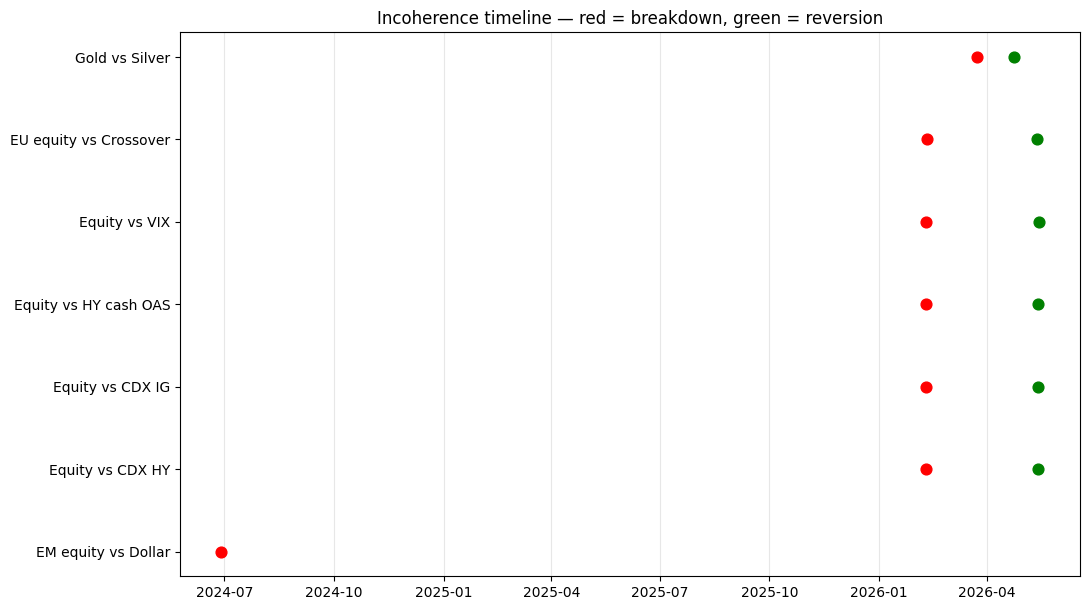

In [5]:
all_events = pd.read_sql("SELECT * FROM events ORDER BY event_date", conn)

if len(all_events) > 0:
    all_events["event_date"] = pd.to_datetime(all_events["event_date"])
    pair_names = list(all_events["pair_name"].unique())

    fig, ax = plt.subplots(figsize=(11, 0.6 * len(pair_names) + 2))
    for i, name in enumerate(pair_names):
        subset = all_events[all_events["pair_name"] == name]
        for _, ev in subset.iterrows():
            color = "red" if ev["event_type"] == "breakdown" else "green"
            ax.scatter(ev["event_date"], i, color=color, s=60, zorder=3)
    ax.set_yticks(range(len(pair_names)))
    ax.set_yticklabels(pair_names)
    ax.set_title("Incoherence timeline — red = breakdown, green = reversion")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No events in the database yet — run notebook 02 first.")